In [1]:
import xarray as xr
import numpy as np
from dask.distributed import Client, LocalCluster
import torch
import xarray as xr
from zarr.codecs import BloscCodec

cluster = LocalCluster(n_workers=10, memory_limit='16GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 10
Total threads: 70,Total memory: 160.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41091,Workers: 10
Dashboard: http://127.0.0.1:8787/status,Total threads: 70
Started: Just now,Total memory: 160.00 GiB
Comm: tcp://127.0.0.1:39509,Total threads: 7
Dashboard: http://127.0.0.1:42801/status,Memory: 16.00 GiB
Nanny: tcp://127.0.0.1:41001,


In [15]:
# era5 = xr.open_zarr(
#     'gs://gcp-public-data-arco-era5/ar/1959-2022-6h-128x64_equiangular_conservative.zarr',
#     chunks=dict(lon=32, lat=32, time=4*365*5, level=1),
#     storage_options=dict(token='anon'),
# )

era5 = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/1959-2022-6h-240x121_equiangular_with_poles_conservative.zarr',
    chunks=dict(longitude=60, latitude=32, time=4*365*5, level=1),
    storage_options=dict(token='anon'),
)


/tmp/ipykernel_559534/40867436.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 7300. This could degrade performance. Instead, consider rechunking after loading.
  era5 = xr.open_zarr(
/tmp/ipykernel_559534/40867436.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 60. This could degrade performance. Instead, consider rechunking after loading.
  era5 = xr.open_zarr(
/tmp/ipykernel_559534/40867436.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 32. This could degrade performance. Instead, consider rechunking after loading.
  era5 = xr.open_zarr(
/tmp/ipykernel_559534/40867436.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "level" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  era5 = xr.open_zarr(


In [21]:
era5_features = era5[['total_column_water_vapour']].rename(total_column_water_vapour='tcwv')
era5_features['u850'] = era5['u_component_of_wind'].sel(level=850, drop=True).rename('u850')
era5_features['v850'] = era5['v_component_of_wind'].sel(level=850, drop=True).rename('v850')
era5_features['w850'] = era5['vertical_velocity'].sel(level=850, drop=True).rename('w850')
era5_features['z850'] = era5['geopotential'].sel(level=850, drop=True).rename('z850')
era5_features['z500'] = era5['geopotential'].sel(level=500, drop=True).rename('z500')
era5_features['t2m'] = era5['2m_temperature'].rename('t2m')
era5_features['slp'] = era5['mean_sea_level_pressure'].rename('slp')



era5_features = era5_features.assign_coords(longitude=(((era5_features.longitude + 180) % 360) - 180)).sortby('longitude')

era5_features_array = era5_features.to_array('var_name').sel(latitude=slice(-5,90)).coarsen(time=4).mean()
                                                            # longitude=slice(-120, 60),
                                                             
era5_features_array_mean = era5_features_array.mean(['time'])
anomaly = era5_features_array - era5_features_array_mean
anomaly_std = anomaly.std(['longitude','latitude','time'])

mask_mean = xr.DataArray([1,1,1,1,1], dims=['var_name'], coords=dict(var_name=['tcwv','u850','v850','z850', 'z500']))
ds_out = xr.Dataset(dict(data_normed=anomaly/anomaly_std,
                         mean_value = era5_features_array_mean,
                         std_value = anomaly_std
                         ),
                    )
ds_out = ds_out.transpose('time','var_name','latitude','longitude').chunk(dict(latitude=32))#.load()


In [ ]:
ds_out

<xarray.Dataset> Size: 11GB
Dimensions:      (latitude: 64, time: 23010, longitude: 240, var_name: 8)
Coordinates:
  * latitude     (latitude) float64 512B -4.5 -3.0 -1.5 0.0 ... 87.0 88.5 90.0
  * time         (time) datetime64[ns] 184kB 1959-01-02T09:00:00 ... 2021-12-...
  * longitude    (longitude) float64 2kB -180.0 -178.5 -177.0 ... 177.0 178.5
  * var_name     (var_name) object 64B 'tcwv' 'u850' 'v850' ... 't2m' 'slp'
Data variables:
    data_normed  (time, var_name, latitude, longitude) float32 11GB dask.array<chunksize=(1825, 1, 32, 60), meta=np.ndarray>
    mean_value   (var_name, latitude, longitude) float32 492kB dask.array<chunksize=(1, 32, 60), meta=np.ndarray>
    std_value    (var_name) float32 32B dask.array<chunksize=(1,), meta=np.ndarray>

In [ ]:
from zarr.codecs import BloscCodec

compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")

ds_out.to_zarr("/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_6H_64x240.zarr", 
               encoding={"data_normed": {"compressors": (compressor,)},
                         "mean_value": {"compressors": (compressor,)},
                         "std_value": {"compressors": (compressor,)},
                         "longitude": {"compressors": (compressor,)},
                         "latitude": {"compressors": (compressor,)},
                         "time": {"compressors": (compressor,)},
                         "var_name": {"compressors": (compressor,)},
                         })


/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/api/asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
2025-05-23 10:10:38,739 - distributed.dashboard.components.sch

In [14]:
ds_out

<xarray.Dataset> Size: 3GB
Dimensions:      (latitude: 32, longitude: 128, var_name: 8, time: 23011)
Coordinates:
  * latitude     (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
  * longitude    (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * var_name     (var_name) object 64B 'tcwv' 'u850' 'v850' ... 't2m' 'slp'
  * time         (time) datetime64[ns] 184kB 1959-01-01 ... 2021-12-31
Data variables:
    data_normed  (time, var_name, latitude, longitude) float32 3GB dask.array<chunksize=(1, 1, 32, 128), meta=np.ndarray>
    mean_value   (var_name, latitude, longitude) float32 131kB dask.array<chunksize=(1, 32, 128), meta=np.ndarray>
    std_value    (var_name) float32 32B dask.array<chunksize=(1,), meta=np.ndarray>

In [9]:
ds_out

<xarray.Dataset> Size: 3GB
Dimensions:      (latitude: 32, longitude: 128, var_name: 8, time: 23011)
Coordinates:
  * latitude     (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
  * longitude    (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * var_name     (var_name) object 64B 'tcwv' 'u850' 'v850' ... 't2m' 'slp'
  * time         (time) datetime64[ns] 184kB 1959-01-01 ... 2021-12-31
Data variables:
    data_normed  (time, var_name, latitude, longitude) float32 3GB dask.array<chunksize=(1, 1, 32, 128), meta=np.ndarray>
    mean_value   (var_name, latitude, longitude) float32 131kB dask.array<chunksize=(1, 32, 128), meta=np.ndarray>
    std_value    (var_name) float32 32B dask.array<chunksize=(1,), meta=np.ndarray>

In [44]:
ds_out

<xarray.Dataset>
Dimensions:      (latitude: 32, longitude: 128, var_name: 8, time: 23011)
Coordinates:
  * latitude     (latitude) float64 1.406 4.219 7.031 ... 82.97 85.78 88.59
  * longitude    (longitude) float64 -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
  * var_name     (var_name) object 'tcwv' 'u850' 'v850' ... 'z500' 't2m' 'slp'
  * time         (time) datetime64[ns] 1959-01-01 1959-01-02 ... 2021-12-31
Data variables:
    data_normed  (time, var_name, latitude, longitude) float32 dask.array<chunksize=(1, 1, 32, 128), meta=np.ndarray>
    mean_value   (var_name, latitude, longitude) float32 dask.array<chunksize=(1, 32, 128), meta=np.ndarray>
    std_value    (var_name) float32 dask.array<chunksize=(1,), meta=np.ndarray>

FileExistsError: file:///Data/gfi/users/rogui7909/data/ERA5/dl_inputs_6H_32x128.zarr is not empty, but `mode` is set to 'w-'.Either remove the existing objects in storage,or set `mode` to a value that handles pre-existing objectsin storage, like `a` or `w`.

In [ ]:
ds_mask = xr.open_dataset('/Data/gfi/users/jodor4442/rainfall_regions/K39_ERA5land_lat_weighted_2d_direct.nc').interp_like(era5_features).tp#.sel(longitude=slice(-12,40), latitude=slice(30,90))
rain = era5['total_precipitation_6hr'].assign_coords(longitude=(((era5_features.longitude + 180) % 360) - 180)).sortby('longitude')
weights = xr.ones_like(ds_mask)*np.cos(np.deg2rad(ds_mask.latitude))
rain_TP = ((weights*rain).groupby(ds_mask).sum()/((weights).groupby(ds_mask).sum())).rename(tp='mask_id')
ds_out['rain_data'] = 
# ds_mask
# ds_mask.tp.plot()
# era5
# rain.groupby()

/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/xarray/core/dataset.py:4597: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explicitly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  stacked_var = exp_var.stack(**{new_dim: dims})
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWar

<xarray.Dataset>
Dimensions:      (latitude: 32, longitude: 128, var_name: 8, time: 23011)
Coordinates:
  * latitude     (latitude) float64 1.406 4.219 7.031 ... 82.97 85.78 88.59
  * longitude    (longitude) float64 -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
  * var_name     (var_name) object 'tcwv' 'u850' 'v850' ... 'z500' 't2m' 'slp'
  * time         (time) datetime64[ns] 1959-01-01 1959-01-02 ... 2021-12-31
Data variables:
    data_normed  (time, var_name, latitude, longitude) float32 dask.array<chunksize=(1, 1, 32, 128), meta=np.ndarray>
    mean_value   (var_name, latitude, longitude) float32 dask.array<chunksize=(1, 32, 128), meta=np.ndarray>
    std_value    (var_name) float32 dask.array<chunksize=(1,), meta=np.ndarray>

In [39]:
rain_TP

<xarray.DataArray (time: 92044, tp: 42)>
dask.array<truediv, shape=(92044, 42), dtype=float64, chunksize=(7300, 1), chunktype=numpy.ndarray>
Coordinates:
    number   int64 0
  * time     (time) datetime64[ns] 1959-01-01 ... 2021-12-31T18:00:00
  * tp       (tp) float64 1.0 3.0 4.0 5.0 5.438 6.0 ... 35.0 36.0 37.0 38.0 39.0

In [29]:
(weights).groupby(ds_mask)

/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


DataArrayGroupBy, grouped over 'tp'
42 groups with labels 1.0, 3.0, 4.0, ..., 37.0, 38.0, 39.0.

In [23]:
rain = era5['total_precipitation_6hr']
weights = xr.ones_like(ds_mask)*np.cos(np.deg2rad(ds_mask.latitude))
rain_TP = ((weights*rain).groupby(ds_mask).sum()/((weights).groupby(ds_mask).sum()))

ValueError: the group variable's length does not match the length of this variable along its dimensions

In [15]:
rain_TP

NameError: name 'rain_TP' is not defined

In [ ]:
ds_out.to_zarr('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_6H_32x128.zarr')

NameError: name 'ds_out' is not defined

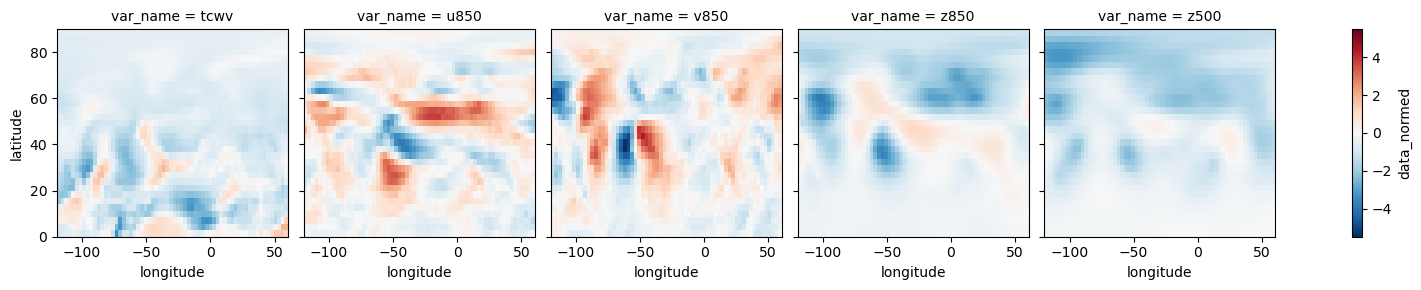

In [5]:
ds_out.data_normed.isel(time=0).plot(col='var_name')

In [7]:
values = ds_out.data_normed.values
np.save('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x64.npy', values)

In [ ]:
ds_in = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32.nc', chunks = dict(var_name=1))
# ds_in.close()
values = ds_in.data_normed.values


2025-02-25 16:10:41,690 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('open_dataset-data_normed-bd4351a1644c257196b07303e508282e', 0, 2, 0, 0))" coro=<Worker.execute() done, defined at /felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/distributed/worker_state_machine.py:3606>> ended with CancelledError
2025-02-25 16:10:41,691 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('open_dataset-data_normed-bd4351a1644c257196b07303e508282e', 0, 1, 0, 0))" coro=<Worker.execute() done, defined at /felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/distributed/worker_state_machine.py:3606>> ended with CancelledError
2025-02-25 16:10:41,691 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('open_dataset-data_normed-bd4351a1644c257196b07303e508282e', 0, 3, 0, 0))" coro=

KeyboardInterrupt: 

Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):


In [9]:
ds_in = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32.nc', chunks = dict(var_name=1)).data_normed
print('wo1')
variables = {str(ds_in.var_name.values[k]):k for k in range(ds_in.var_name.size)}
variables

wo1


{'tcwv': 0, 'u850': 1, 'v850': 2, 'z850': 3, 'z500': 4}

In [17]:
input_variable = [ 'u850']

ds_in = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32.nc', chunks = dict(var_name=1)).data_normed
print('wo1')
variables = {str(ds_in.var_name.values[k]):k for k in range(ds_in.var_name.size)}
ds_in = ds_in.sel(var_name=input_variable)
input_indices = [variables[k] for k in input_variable]
data_in = np.load('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32.npy',allow_pickle=True )#[:,input_indices]
print('wo2')

data_in

wo1
wo2


array(<bound method Mapping.values of <xarray.Dataset> Size: 945MB
Dimensions:       (latitude: 32, longitude: 32, var_name: 5, time: 23011)
Coordinates:
  * latitude      (latitude) float64 256B 1.406 4.219 7.031 ... 85.78 88.59
  * longitude     (longitude) float64 256B -47.81 -45.0 -42.19 ... 36.56 39.38
  * var_name      (var_name) <U4 80B 'tcwv' 'u850' 'v850' 'z850' 'z500'
  * time          (time) datetime64[ns] 184kB 1959-01-01 ... 2021-12-31
Data variables:
    data_normed   (time, var_name, latitude, longitude) float64 943MB dask.array<chunksize=(23011, 1, 32, 32), meta=np.ndarray>
    mean_value    (time, var_name) float64 920kB dask.array<chunksize=(23011, 1), meta=np.ndarray>
    std_value     (time, var_name) float64 920kB dask.array<chunksize=(23011, 1), meta=np.ndarray>
    mean_removed  (var_name) int64 40B dask.array<chunksize=(1,), meta=np.ndarray>>,
      dtype=object)

# compute curl

In [ ]:
ds_in = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32.nc')


# Constants
g = 9.81  # Gravity (m/s^2)
Omega = 7.292e-5  # Earth's rotation rate (s^-1)

def coriolis_parameter(latitude):
    """Compute Coriolis parameter f at given latitudes."""
    return 2 * Omega * np.sin(np.deg2rad(latitude))

def geostrophic_winds(geo_height, latitudeitude, longitude):
    """
    Compute geostrophic wind components (u_g, v_g) from geopotential height.

    Parameters:
    geo_height : xarray.DataArray
        Geopotential height field with dimensions (latitude, longitude).
    latitude : xarray.DataArray
        latitude values.
    longitude : xarray.DataArray
        longitudegitude values.

    Returns:
    u_g, v_g : xarray.DataArray
        Geostrophic wind components (m/s).
    """
    f = coriolis_parameter(latitude)  # Compute Coriolis parameter
    
    # Compute horizontal gradients using xarray's differentiation
    dZ_dy = geo_height.differentiate("latitude") / 111000  # Convert degrees to meters
    dZ_dx = geo_height.differentiate("longitude") / (111000 * np.cos(np.deg2rad(latitude)))  # Adjust for longitudegitude scaling
    
    # Compute geostrophic wind components
    u_g = - (g / f) * dZ_dy
    v_g = (g / f) * dZ_dx
    
    return u_g, v_g

# Example usage with a dataset
# geo_height = ds_in["z500"]  # Replace "Z" with the actual variable name
latitude = ds_in["latitude"]
longitude = ds_in["longitude"]

u850_g, v850_g = geostrophic_winds(ds_in.data_normed.sel(var_name="z850"), latitude, longitude)
u500_g, v500_g = geostrophic_winds(ds_in.data_normed.sel(var_name="z500"), latitude, longitude)
ds_in_add = xr.concat([u850_g.assign_coords(var_name='u850_g'),
                       v850_g.assign_coords(var_name='v850_g'),
                       u500_g.assign_coords(var_name='u500_g'),
                       v500_g.assign_coords(var_name='v500_g')], dim='var_name')

# Add to dataset if needed
# Save or analyze the output
ds_out = xr.merge([ds_in,ds_in_add.rename('data_normed')])
ds_out.var_name.encoding = {'dtype': '<U6'}
ds_out.to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32_geostroph.nc')

In [ ]:
ds = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32_geostroph.nc')
ds_out = ds.transpose('time','var_name','latitude','longitude')
u850_ag = (ds_out.sel(var_name='u850')[['data_normed']] - ds_out.sel(var_name='u850_g')[['data_normed']]).assign_coords(var_name='u850_ag')
v850_ag = (ds_out.sel(var_name='v850')[['data_normed']] - ds_out.sel(var_name='v850_g')[['data_normed']]).assign_coords(var_name='v850_ag')
ds_out2 = xr.concat([ds_out, u850_ag, v850_ag], dim='var_name')
ds_out2.mean_removed.values = [1,0,0,0,0,0,0,0,1,0,0]
ds_out2.to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32_ageostroph.nc')

In [55]:
ds_out = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x32_geostroph.nc')
# ds_out.sel(var_name='u850_g')
ds_out.var_name

<xarray.DataArray 'var_name' (var_name: 9)> Size: 216B
array(['tcwv', 'u500_g', 'u850', 'u850_g', 'v500_g', 'v850', 'v850_g', 'z500',
       'z850'], dtype='<U6')
Coordinates:
  * var_name  (var_name) <U6 216B 'tcwv' 'u500_g' 'u850' ... 'z500' 'z850'

In [30]:
ds_out.data_normed.values.shape

(23011, 9, 32, 32)

In [18]:
data=  era5_features.u850.isel(time=0).load()

In [22]:
data.sel(longitude=slice(-50,42),latitude=slice(0,90))

<xarray.DataArray 'u850' (longitude: 32, latitude: 32)> Size: 4kB
array([[-9.3948917e+00, -8.0623636e+00, -7.0682917e+00, ...,
        -7.0592843e-02,  2.2264652e+00,  1.6002868e+00],
       [-8.9804630e+00, -8.4344177e+00, -6.7126689e+00, ...,
         3.0978599e-03,  2.3072870e+00,  1.6983421e+00],
       [-8.2354860e+00, -8.7053480e+00, -7.0348372e+00, ...,
         1.3868183e-01,  2.3848023e+00,  1.7905636e+00],
       ...,
       [-2.7196548e+00, -6.8852391e+00, -1.3337133e+00, ...,
        -2.2063532e+00, -6.8430883e-01,  4.5552680e-01],
       [-3.9394259e+00, -9.4559002e+00, -1.0458354e-01, ...,
        -2.6473794e+00, -2.3256190e-01,  3.9519259e-01],
       [-5.0830889e+00, -5.4648156e+00, -7.9500955e-01, ...,
        -2.6599379e+00,  2.4948396e-01,  3.4977823e-01]], dtype=float32)
Coordinates:
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
    time       datetime64[ns] 8B 1959-01-01
  * longitude  (longitude) float64 256B -47.81 -45.0 -42.19 ... 36.56 39.38
Attributes:
    long_name:      U component of wind
    short_name:     u
    standard_name:  eastward_wind
    units:          m s**-1

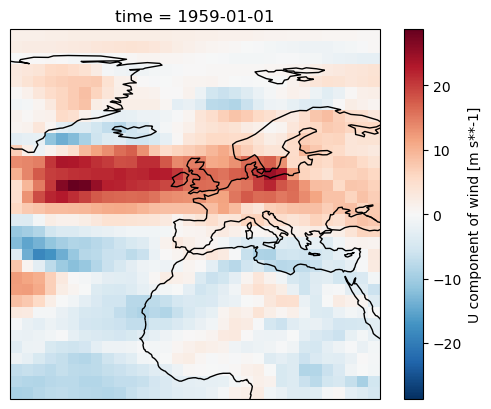

In [23]:
import cartopy.crs as ccrs
plot = data.sel(longitude=slice(-50,42),latitude=slice(0,90)).plot(x='longitude', y='latitude', subplot_kws=dict(projection=ccrs.PlateCarree()), transform =ccrs.PlateCarree())
plot.axes.coastlines()

In [ ]:
precip = era5['total_precipitation_6hr']*1000
precip_out = precip.sel(latitude=slice(0,90)).resample(time='D').sum(keep_attrs=True).rename('pr').to_dataset()
precip_out['mean_pr'] = precip_out.pr.weighted(np.cos(np.deg2rad(precip_out.latitude))).mean(['longitude','latitude','time'])
precip_out['std_pr'] = precip_out.pr.weighted(np.cos(np.deg2rad(precip_out.latitude))).std(['longitude','latitude','time'])

precip_out.assign_coords(longitude=(((precip_out.longitude + 180) % 360) - 180)).sortby('longitude').to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/pr.nc')


In [32]:
tcwv = era5['total_column_water_vapour']
tcwv_out = tcwv.sel(latitude=slice(0,90)).resample(time='D').mean(keep_attrs=True).rename('tcwv').to_dataset()
tcwv_out['mean_tcwv'] = tcwv_out.tcwv.weighted(np.cos(np.deg2rad(tcwv_out.latitude))).mean(['longitude','latitude','time'])
tcwv_out['std_tcwv'] = tcwv_out.tcwv.weighted(np.cos(np.deg2rad(tcwv_out.latitude))).std(['longitude','latitude','time'])

tcwv_out.assign_coords(longitude=(((tcwv_out.longitude + 180) % 360) - 180)).sortby('longitude').to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/tcwv.nc')

In [29]:
uwind = era5['u_component_of_wind'].sel(level=850, drop=True).rename('u850')
uwind_out = uwind.sel(latitude=slice(0,90)).resample(time='D').mean(keep_attrs=True).rename('u850').to_dataset()
uwind_out['mean_u850'] = uwind_out.u850.weighted(np.cos(np.deg2rad(uwind_out.latitude))).mean(['longitude','latitude','time'])
uwind_out['std_u850'] = uwind_out.u850.weighted(np.cos(np.deg2rad(uwind_out.latitude))).std(['longitude','latitude','time'])

uwind_out.assign_coords(longitude=(((uwind_out.longitude + 180) % 360) - 180)).sortby('longitude').to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/u850.nc')

2025-02-13 12:46:12,249 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.66 GiB -- Worker memory limit: 8.00 GiB
2025-02-13 12:46:14,449 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.56 GiB -- Worker memory limit: 8.00 GiB
2025-02-13 12:46:15,983 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- U

In [30]:
vwind = era5['v_component_of_wind'].sel(level=850, drop=True).rename('v850')
vwind_out = vwind.sel(latitude=slice(0,90)).resample(time='D').mean(keep_attrs=True).rename('v850').to_dataset()
vwind_out['mean_v850'] = vwind_out.v850.weighted(np.cos(np.deg2rad(vwind_out.latitude))).mean(['longitude','latitude','time'])
vwind_out['std_v850'] = vwind_out.v850.weighted(np.cos(np.deg2rad(vwind_out.latitude))).std(['longitude','latitude','time'])

vwind_out.assign_coords(longitude=(((vwind_out.longitude + 180) % 360) - 180)).sortby('longitude').to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/v850.nc')

2025-02-13 12:55:05,337 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.63 GiB -- Worker memory limit: 8.00 GiB
2025-02-13 12:55:08,092 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.63 GiB -- Worker memory limit: 8.00 GiB
2025-02-13 12:55:18,144 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- U

In [22]:
z500 = era5['geopotential'].sel(level=850, drop=True).rename('z500')
z500_out = z500.sel(latitude=slice(0,90)).resample(time='D').mean(keep_attrs=True).rename('z500').to_dataset()
z500_out['mean_z500'] = z500_out.z500.weighted(np.cos(np.deg2rad(z500_out.latitude))).mean(['longitude','latitude','time'])
z500_out['std_z500'] = z500_out.z500.weighted(np.cos(np.deg2rad(z500_out.latitude))).std(['longitude','latitude','time'])

z500_out.assign_coords(longitude=(((z500_out.longitude + 180) % 360) - 180)).sortby('longitude').to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/z500.nc')

# make tensor

In [2]:

process_variables = dict(z500='standard',
                         u850='std_only',
                         v850='std_only',
                         tcwv='standard',
                         pr='standard'
                            )

In [3]:
variables = ['z500','u850','v850','tcwv','pr']
lon_extent = slice(-90,89.5)
lat_extent = slice(20,90)

print('loading data ...')
all_data_in = dict()
for variable in variables:
    with xr.open_dataset(f'/Data/gfi/users/rogui7909/data/ERA5/{variable}.nc', chunks = dict(longitude=50, latitude=50, time=365*10)) as ds:
        data_ = ds.sel(latitude=lat_extent, longitude=lon_extent)[variable]
        time = ds.time
        if process_variables[variable] == 'standard':
            data_ = (data_ - ds[f'mean_{variable}'].values)/ds[f'std_{variable}'].values
        elif process_variables[variable] == 'std_only':
            data_ = (data_)/ds[f'std_{variable}'].values
        all_data_in[variable]=data_
        print('   --> ',variable,'loaded')
data_in = xr.Dataset(all_data_in).to_array('var_name')
# data_in = data_in.transpose(1,0,2,3)
print('Input data ready')

# tensor_in = torch.Tensor(data_in).type(torch.float32)

loading data ...
   -->  z500 loaded
   -->  u850 loaded
   -->  v850 loaded
   -->  tcwv loaded
   -->  pr loaded
Input data ready


In [1]:
import numpy as np
import h5py



In [2]:
data = np.load( "/Data/gfi/users/rogui7909/data/ERA5/numpy_era5_in.npy")

In [ ]:
h5f = h5py.File('/Data/gfi/users/rogui7909/data/ERA5/era5_in_data.h5', 'w')
h5f.create_dataset('z500', data=data[:,0])
h5f.create_dataset('u850', data=data[:,1])
h5f.create_dataset('v850', data=data[:,2])
h5f.create_dataset('tcwv', data=data[:,3])
h5f.create_dataset('pr', data=data[:,4])

h5f.close()

In [15]:
h5f = h5py.File('/Data/gfi/users/rogui7909/data/ERA5/era5_in_data.h5', 'r')


In [ ]:
h5f['u850'][:]

In [ ]:
    variable_order = dict(z500=0,u850=1,v850=2,tcwv=3,pr=4)


<HDF5 dataset "pr": shape (23011, 100, 256), type "<f8">

In [ ]:
h5f.create_dataset('v850', data=data[:,0])
h5f.create_dataset('u850', data=data[:,0])
h5f.create_dataset('u850', data=data[:,0])
h5f.create_dataset('u850', data=data[:,0])


In [ ]:
import numpy as np
import h5py

a = np.random.random(size=(100,20))
h5f = h5py.File('data.h5', 'w')
h5f.create_dataset('dataset_1', data=a)
# <HDF5 dataset "dataset_1": shape (100, 20), type "<f8">

In [4]:
data_in = data_in.transpose('time','var_name','latitude','longitude').load()
# to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/era5_in_data.h5', engine="h5netcdf")

In [ ]:
data_dict = data_in.to_dict(data=True)

: 

: 

: 

: 

In [ ]:
import h5py

In [ ]:
with h5py.File('/Data/gfi/users/rogui7909/data/ERA5/era5_in_data.h5', "w") as f:
    for var, values in data_dict["data_vars"].items():
        f.create_dataset(var, data=values["data"])

In [ ]:
data_in.to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/era5_in_data.h5', engine="h5netcdf")

In [ ]:
data_numpy = data_in.transpose('time','var_name','latitude','longitude').values

# to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/era5_in_data.nc')

In [ ]:
data_torch = torch.Tensor(data_numpy)

In [ ]:
np.save( "/Data/gfi/users/rogui7909/data/ERA5/numpy_era5_in.npy", data_numpy)

2025-02-14 12:13:55,081 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/distributed/worker.py", line 1269, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/distributed/utils_comm.py", line 441, in retry_operation
    return await retry(
           ^^^^^^^^^^

In [1]:
import torch

In [2]:
tensor_in = torch.load("/Data/gfi/users/rogui7909/data/ERA5/tensor_era5_in.pt", weights_only=True)

In [6]:
tensor_in.transpose(1,0,2,3)

TypeError: transpose() received an invalid combination of arguments - got (int, int, int, int), but expected one of:
 * (int dim0, int dim1)
 * (name dim0, name dim1)
